In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from burst_toolbox.coupling import phase_histogram, phase_burst_coupling, phase_amplitude_coupling
from burst_toolbox.dsp import compute_amplitude

In [3]:
# Load example data

# Parameters
channel_of_phase = 5
channel_of_activity = 64
phase_freq_band = np.array([12, 30])
activity_freq_band = np.array([70, 140])

LFP_df = pd.read_csv("UT1_LMFG-5_RMTG-64_correct-trials_LFP.csv")
LFP_slow = LFP_df[LFP_df["channel"] == channel_of_phase][[f"LFP_{k}" for k in range(6499)]].to_numpy()
LFP_fast = LFP_df[LFP_df["channel"] == channel_of_activity][[f"LFP_{k}" for k in range(6499)]].to_numpy()
LFP_df = None

# Bursts from channel_of_activity
bursts = pd.read_csv("UT1_LMFG-5_RMTG-64_correct-trials_bursts.csv")
bursts = bursts[[f"burst_{k}" for k in range(6499)]].to_numpy()

In [4]:
# Compute amplitude and estimate PAC
LFP_fast_amplitude = compute_amplitude(LFP_fast, activity_freq_band)
LFP_fast_amplitude = LFP_fast_amplitude / np.nanmean(LFP_fast_amplitude[:, 100 : 900])

phase_amplitude_counts, _ = phase_histogram(
    LFP = LFP_slow, 
    events = LFP_fast_amplitude, 
    phase_freq_band = phase_freq_band
)

pac, _ = phase_amplitude_coupling(phase_amplitude_counts, win_len = 150, right_edge_effect = "nan")

In [5]:
# Estimate PBC
phase_burst_counts, _ = phase_histogram(
        LFP = LFP_slow, 
        events = bursts, 
        phase_freq_band = phase_freq_band
    )

pbc, _ = phase_burst_coupling(phase_burst_counts, win_len = 150, gamma = 90, right_edge_effect = "nan", drop_negative_values = True)

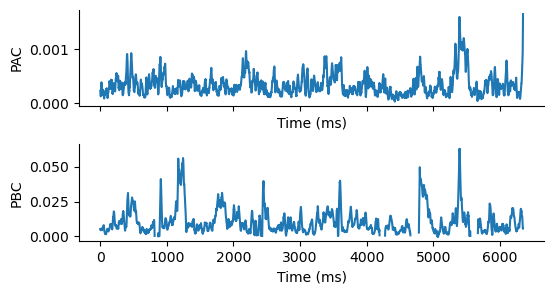

In [6]:
fig, ax = plt.subplots(2, 1, figsize = (6, 3), sharex = True)

config = {
    0: {
        "ylabel": "PAC"
    },
    1: {
        "ylabel": "PBC"
    }
}

for row_idx, trace in enumerate([pac, pbc]):
    ca = ax[row_idx]
    ca.plot(trace)

    ca.set_xlabel("Time (ms)")
    ca.set_ylabel(config[row_idx]["ylabel"])
    ca.spines[["top", "right"]].set_visible(False)

plt.subplots_adjust(hspace = 0.4)
fig.align_labels()